<a href="https://colab.research.google.com/github/be-great/Big_Data_Analytics_in_Healthcare/blob/main/Visulaize.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!pip install pyspark==3.5.3

/tmp/ipython-input-2802502244.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="gender", y="count", data=gender_counts, palette="pastel")


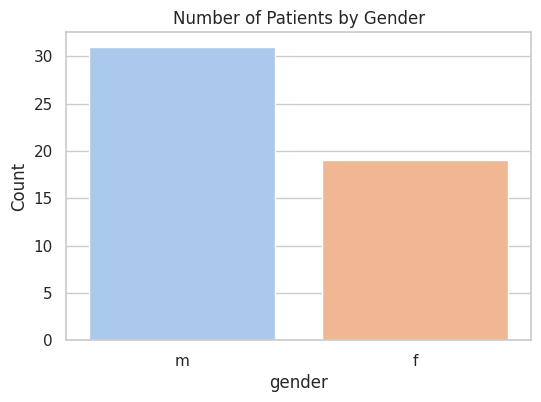

/tmp/ipython-input-2802502244.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="hospital_branch", y="avg_experience", data=branch_exp, palette="muted")


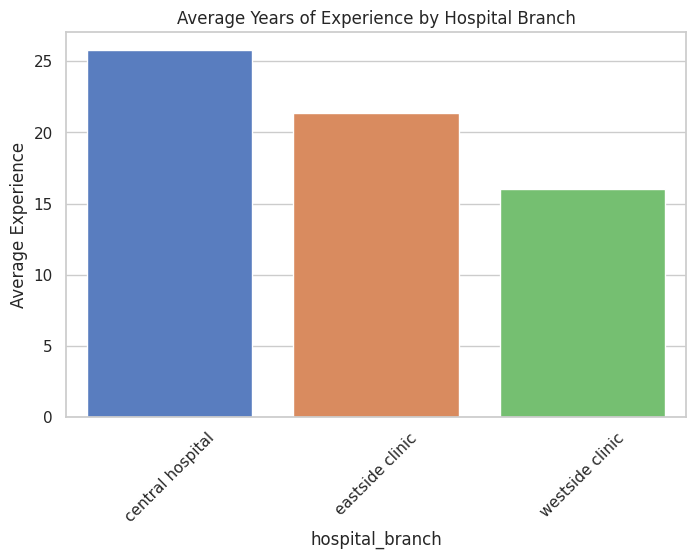

/tmp/ipython-input-2802502244.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="specialization", y="count", data=spec_count, palette="bright")


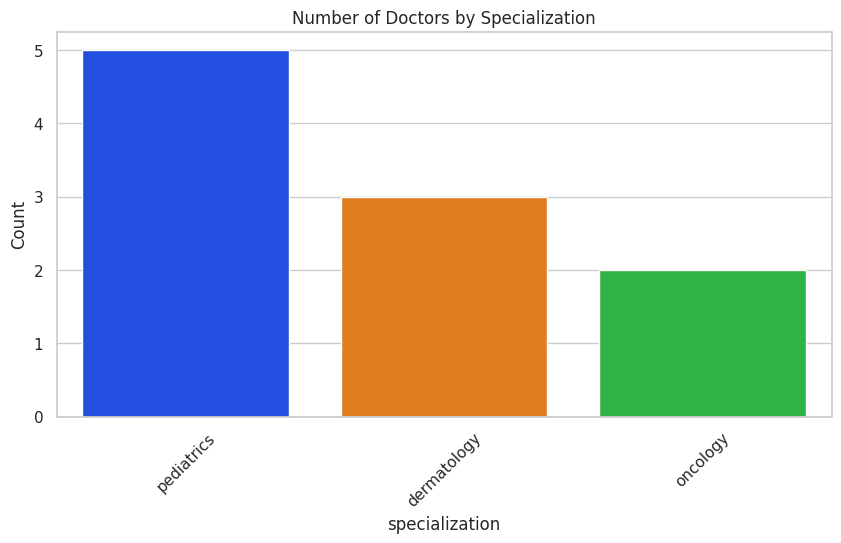

/tmp/ipython-input-2802502244.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="reason_for_visit", y="count", data=reason_count, palette="deep")


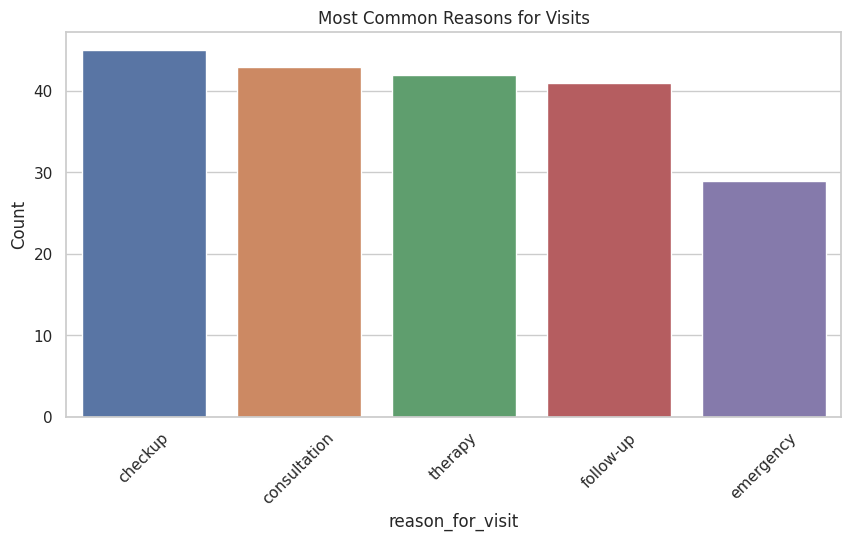

/tmp/ipython-input-2802502244.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="treatment_type", y="avg_cost", data=treatment_cost, palette="coolwarm")


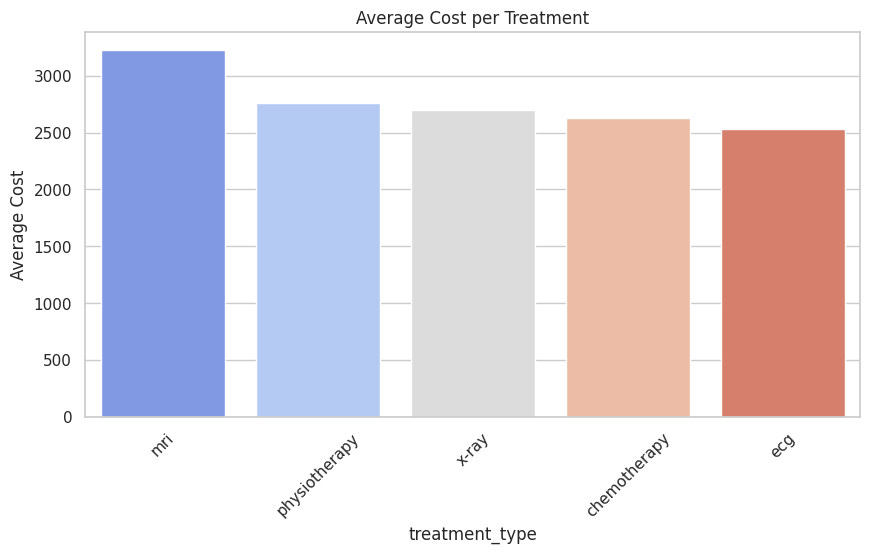

In [4]:
# =========================================
# 1- Import Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import avg # Added import for avg
sns.set(style="whitegrid")

spark = SparkSession.builder.appName("HospitalML").getOrCreate()
base = "/content/Big_Data_Analytics_in_Healthcare/data/curated_parquet"  # Update with your path

# =========================================
# 1- Load Datasets
patients_c = spark.read.parquet(f"{base}/patients.parquet")
appts_c    = spark.read.parquet(f"{base}/appointments.parquet")
treats_c   = spark.read.parquet(f"{base}/treatments.parquet")
bill_c     = spark.read.parquet(f"{base}/billing.parquet")
doctors_c     = spark.read.parquet(f"{base}/doctors.parquet")


# =========================================
# 2️- Question A: Gender distribution
gender_counts = patients_c.groupBy("gender").count().toPandas()

plt.figure(figsize=(6,4))
sns.barplot(x="gender", y="count", data=gender_counts, palette="pastel")
plt.title("Number of Patients by Gender")
plt.ylabel("Count")
plt.show()

# =========================================
# 3️-  Question B: Average experience per hospital branch
branch_exp = doctors_c.groupBy("hospital_branch") \
    .agg(avg("years_experience").alias("avg_experience")) \
    .orderBy("avg_experience", ascending=False).toPandas()

plt.figure(figsize=(8,5))
sns.barplot(x="hospital_branch", y="avg_experience", data=branch_exp, palette="muted")
plt.title("Average Years of Experience by Hospital Branch")
plt.ylabel("Average Experience")
plt.xticks(rotation=45)
plt.show()

# =========================================
# 4️- Question C: Number of doctors by specialization
spec_count = doctors_c.groupBy("specialization").count().orderBy("count", ascending=False).toPandas()

plt.figure(figsize=(10,5))
sns.barplot(x="specialization", y="count", data=spec_count, palette="bright")
plt.title("Number of Doctors by Specialization")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# =========================================
# 5️- Question D: Most common reasons for visits
reason_count = appts_c.groupBy("reason_for_visit").count().orderBy("count", ascending=False).toPandas()

plt.figure(figsize=(10,5))
sns.barplot(x="reason_for_visit", y="count", data=reason_count, palette="deep")
plt.title("Most Common Reasons for Visits")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# =========================================
# 6️- Question E: Treatments ranked by average cost
treatment_cost = bill_c.join(treats_c, "treatment_id") \
    .groupBy("treatment_type").agg(avg("cost").alias("avg_cost")) \
    .orderBy("avg_cost", ascending=False).toPandas()

plt.figure(figsize=(10,5))
sns.barplot(x="treatment_type", y="avg_cost", data=treatment_cost, palette="coolwarm")
plt.title("Average Cost per Treatment")
plt.ylabel("Average Cost")
plt.xticks(rotation=45)
plt.show()